In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import BayesianRidge
from numpy import log10 as log
import sys
from pathlib import Path

current_path = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in [current_path, *current_path.parents]
     if (p / "Scripts").is_dir()),
    None
)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from within the repository.")
scripts_directory = PROJECT_ROOT / 'Scripts' / 'Helpers'

# Convert the Path object to a string and append it to sys.path
if str(scripts_directory) not in sys.path:
    sys.path.append(str(scripts_directory))
from Helpers import *

In [2]:
df_Bankruptcy = pd.read_csv(PROJECT_ROOT/"Data/Proxies/Bankruptcy/Bankruptcy_Proxy_Normalized.csv")
y_Bankruptcy_data = df_Bankruptcy["Bankruptcy"].values
x_Bankruptcy_data = df_Bankruptcy["Bankruptcy filings"].values
y_Bankruptcy_label = "Supply"
x_Bankruptcy_label = "Bankruptcy filings"


df_Crime = pd.read_csv(PROJECT_ROOT/"Data/Proxies/Crime/Crime_Proxy_Normalized.csv")
y_Crime_data = df_Crime["Criminal_Defense"].values
x_Crime_data = df_Crime["Number_of_arrests"].values
y_Crime_label = "Supply"
x_Crime_label = "Total arrests"


df_Family = pd.read_csv(PROJECT_ROOT/"Data/Proxies/Family/Family_Proxy_Normalized.csv")
y_Family_data = df_Family["Family"].values
x_Family_data = df_Family["Female_Divorces"].values
y_Family_label = "Supply"
x_Family_label = "Divorced females"


df_Immigration = pd.read_csv(PROJECT_ROOT/"Data/Proxies/Immigration/Immigration_Proxy_Normalized.csv")
y_Immigration_data = df_Immigration["Immigration"].values
x_Immigration_data = df_Immigration["Foreign_Born_Population"].values
y_Immigration_label = "Supply"
x_Immigration_label = "Foreign born population"

df_IP = pd.read_csv(PROJECT_ROOT/"Data/Proxies/Intellectual Property/Intellectual_Property_Proxy_Normalized.csv")
y_IP_data = df_IP["Intellectual Property"].values
x_IP_data = df_IP["Patents"].values
y_IP_label = "Supply"
x_IP_label = "Granted patents"


df_RS = pd.read_csv(PROJECT_ROOT/"Data/Proxies/Real Estate/Real_Estate_Proxy_Normalized.csv")
y_RS_data = df_RS["Real Estate"].values
x_RS_data = df_RS["Total_Transaction_Value_2024_millions"].values
y_RS_label = "Supply"
x_RS_label = "Total transaction value (million $)"

In [3]:
plt.rcParams.update({
    'axes.titlesize': 20,      # plot titles
    'axes.labelsize': 22,      # x and y labels
    'xtick.labelsize': 22,     # x-axis tick labels
    'ytick.labelsize': 22,     # y-axis tick labels
    'legend.fontsize': 24,
    "font.family":"arial",
    #"font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "mathtext.default": "rm",
    "mathtext.rm"  : "arial",# legend
})

382
380
363
364
332
278


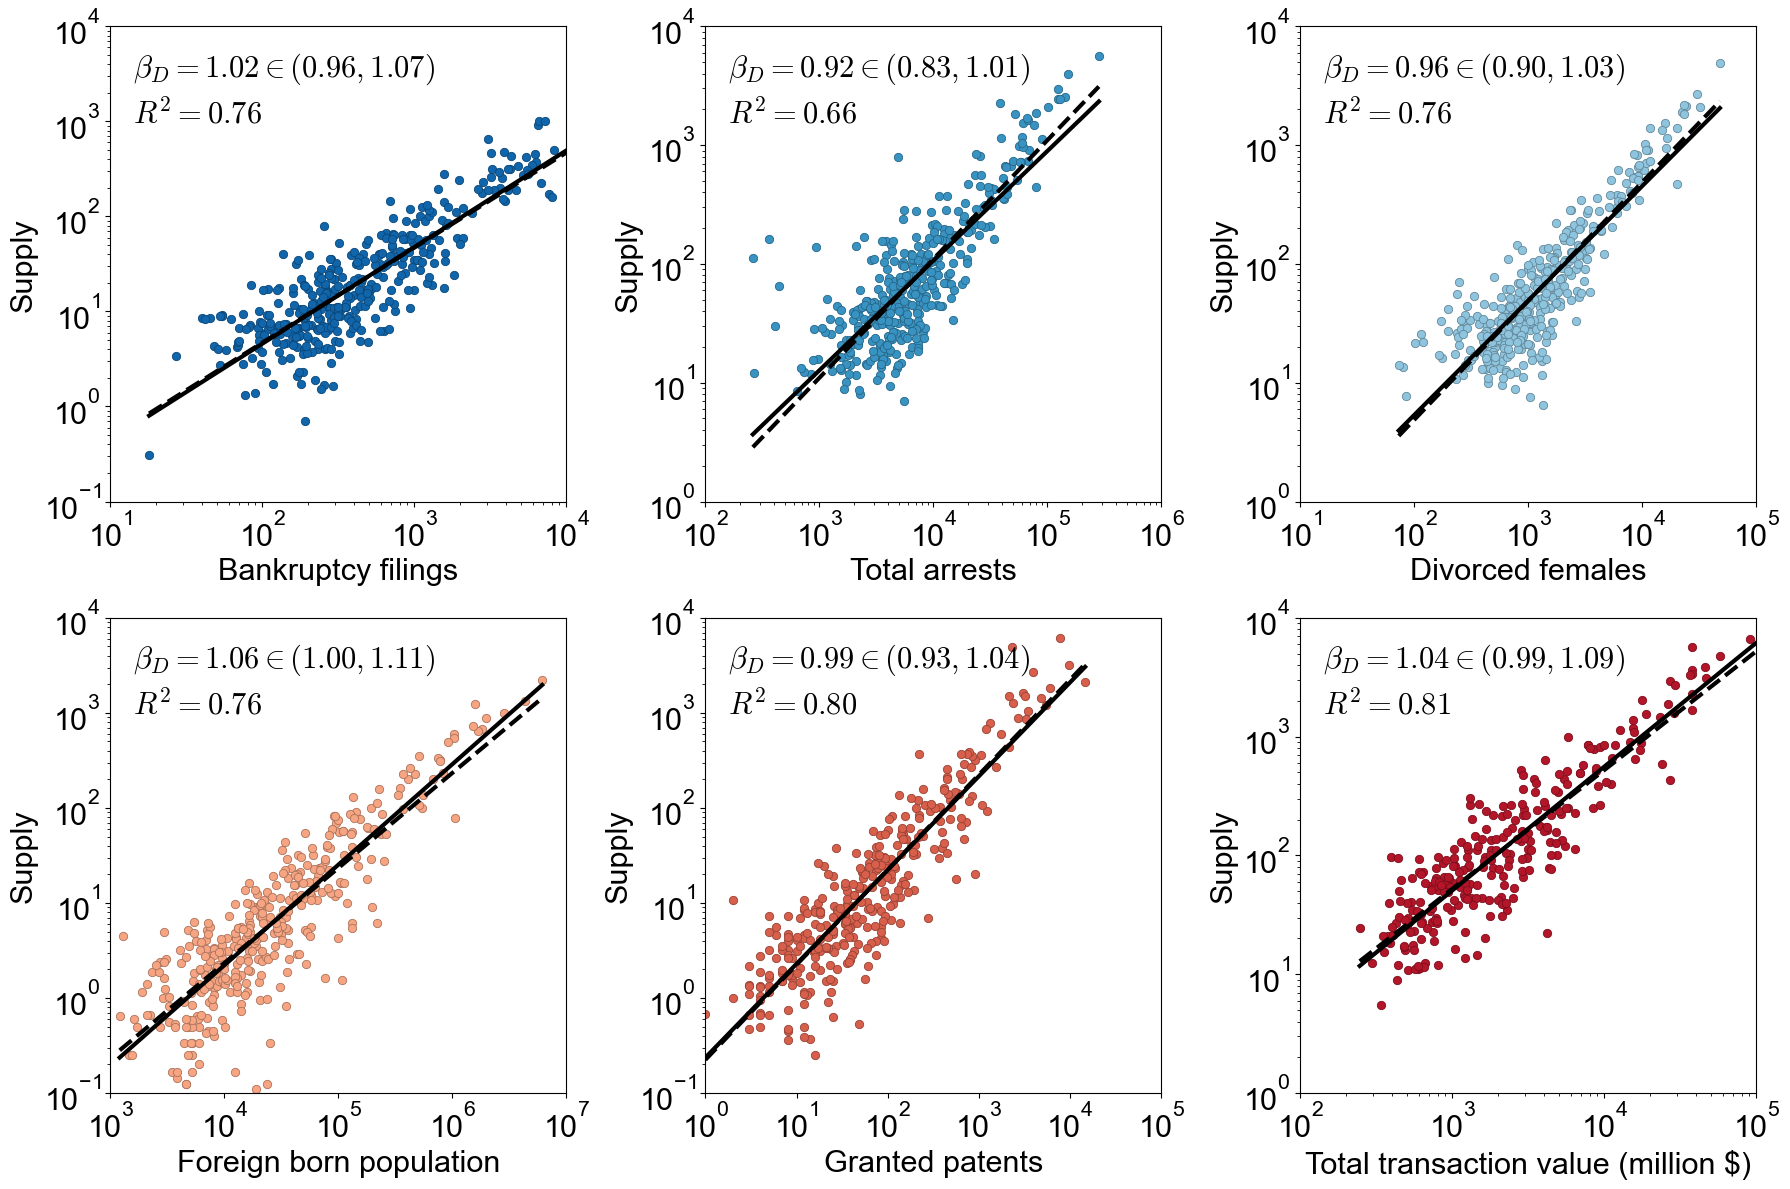

In [6]:
colors = ["#1065ab", "#3893c3", "#8ec4de", "#f6a482", "#d75f4c", "#b31529"]

datasets = [
    (x_Bankruptcy_data, y_Bankruptcy_data, x_Bankruptcy_label, y_Bankruptcy_label),
    (x_Crime_data,       y_Crime_data,       x_Crime_label,       y_Crime_label),
    (x_Family_data,      y_Family_data,      x_Family_label,      y_Family_label),
    (x_Immigration_data, y_Immigration_data, x_Immigration_label, y_Immigration_label),
    (x_IP_data,          y_IP_data,          x_IP_label,          y_IP_label),
    (x_RS_data,          y_RS_data,          x_RS_label,          y_RS_label),
]

# (xmin_exp, xmax_exp, ymin_exp, ymax_exp) for each subplot
limits = [
    (1, 4, -1, 4),
    (2, 6, 0, 4),
    (1, 5, 0, 4),
    (3, 7, -1, 4),
    (0, 5, -1, 4),
    (2, 5, 0, 4),
]


fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for ax, (data, color, lim) in zip(axes, zip(datasets, colors, limits)):
    x, y, xlab, ylab = data
    plot_panel(ax, x, y, xlab, ylab, color, lim)

plt.tight_layout()
# Define the output directory and ensure it exists
save_dir = PROJECT_ROOT / "Figures/Supplementary Figure 6"
save_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(save_dir / "Supplementary_Figure_6.pdf", bbox_inches='tight')
plt.show()